**# Decision Tree Modeling**

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, sys

In [4]:
from sklearn.preprocessing import StandardScaler #statndardize features by removing the mean and scaling to unit variance
from sklearn.model_selection import train_test_split #split arrays or matrices into random train and test subsets
import sys # for manipulating the Python runtime environment
import os # for interacting with the operating system

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd() # Get the current directory

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
# Ensure the parent directory is in sys.path so we can import modules from it
# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
from field import Field



from data_creator import load_2D
df = load_2D().dropna() # load data from files
#print("Rows before dropna:", load_2D().shape[0])
#print("Rows after dropna:", df.shape[0])
#print(df.isna().sum())

# split data into X and y

X = df[['Area', 'Circumference', 'MU', "Span" ,'CoA','MCS']]#"MCS" and 'CoA' are removed from X temporarily
y = (df["AD"] > df["ADPass"]).astype(int)

# # scale X
scale = StandardScaler()
scaled_X = scale.fit_transform(X)

# # train test split
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 4)


2401961
2401890
2401613
2402012
2401976
2401960
2401761
2402015
2401658
2401659
2401839
2401614
2402014
2401842
2401841
2401898
2401965
2401899
2401840
2401888
2401758
2402027
2401963
2401762
2402010
2401962
2402026
2401759
2401889
2415430
2415650
2415743
2415651
2415590
2415708
2415745
2415591
2415707
2415428
2415429
2410583
2410540
2410541
2410845
2410582
2410585
2410726
2410727
2410584
2410581
2410580
2409014
2409130
2408961
2408936
2408960
2409015
2409065
2408951
2408950
2409068
2408898
2409067
2408986
2408987
2409016
2408934
2408830
2408831
2408935
2408954
2403177
2403346
2403106
2403370
2402956
2403329
2402962
2403105
2403369
2403178
2403247
2415735
Skipping broken file in load_2D: /Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset/2024-02-09/FieldID_2415735.json - Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 0)
2416174
2416142
2416007
2416314


In [5]:
# Decision Tree Classifier
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)
y_prob = tree_clf.predict_proba(X_test)[:, 1]

### Results

In [6]:
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
print("Decision Tree Classifier:")
print(f"Accuracy : {acc:.4f}")
print(f"ROC AUC  : {roc:.4f}")


Decision Tree Classifier:
Accuracy : 0.9061
ROC AUC  : 0.6565


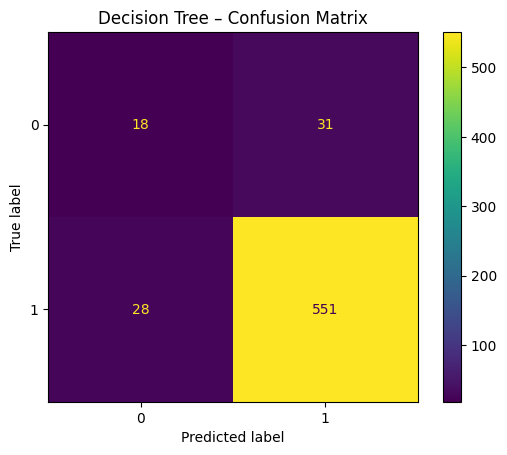

In [7]:

# Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
cm.ax_.set_title("Decision Tree – Confusion Matrix")
plt.show()

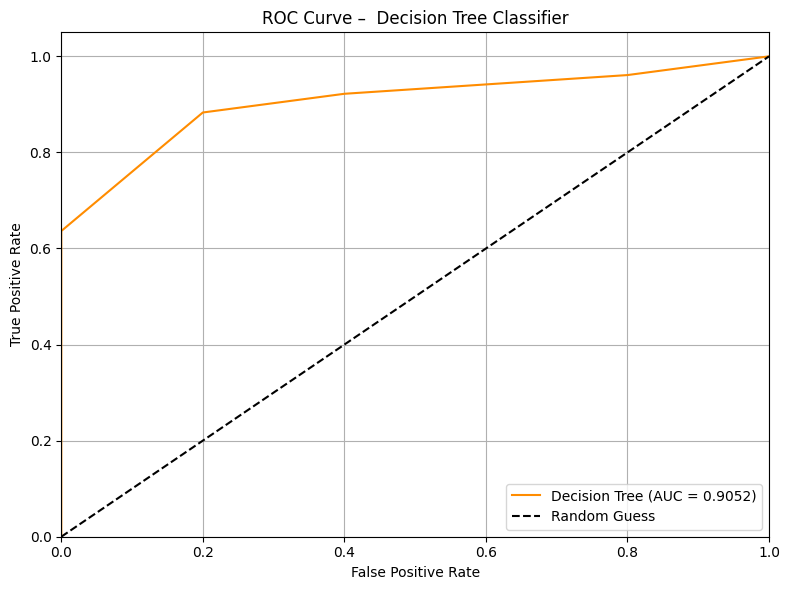

In [42]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score


# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# --- Plot ROC ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve –  Decision Tree Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("xgboost_roc_curve.png")
plt.show()
